# Regresión Logística

En este ejercicio aplicamos regresión logística para clasificar correos electrónicos como SPAM o HAM (no spam), usando el dataset TREC 2007 preprocesado de Kaggle.
A diferencia de la regresión lineal que predice valores continuos, la regresión logística predice probabilidades mediante la función sigmoide:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = \theta_0 + \theta_1 x_1 + ... + \theta_n x_n$$

La salida siempre estará entre 0 y 1, interpretándose como la probabilidad de que el correo sea SPAM.

Para acceder al dataset online entrar [aquí](https://www.kaggle.com/datasets/imdeepmind/preprocessed-trec-2007-public-corpus-dataset).

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

%matplotlib inline

# 1. Carga del Dataset

In [6]:
df = pd.read_csv("data/processed_data.csv")
print(df.shape)
df.head()

(75419, 5)


,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...


In [5]:
print("Distribución de clases:")
print(df['label'].value_counts())

Distribución de clases:
label
1    50199
0    25220
Name: count, dtype: int64


# 2. Preprocesamiento del Texto

El algoritmo no puede trabajar con texto directamente, sino con números. Se utiliza 'CountVectorizer' para convertir cada correo en un vector que cuente cuántas veces aparece cada palabra del vocabulario.

In [7]:
# Se combina asunto y cuerpo en una sola cadena de texto por correo
df['text'] = df['subject'].fillna('') + ' ' + df['message'].fillna('')

In [8]:
# Se mantiene el orden temporal del dataset para simular un escenario real:
# entrenamos con correos antiguos y predecimos sobre correos más recientes
split = int(len(df) * 0.8)

X_train_raw = df['text'][:split] # desde la posición 0 hasta split-1
X_test_raw  = df['text'][split:] # desde split hasta el final
y_train = df['label'][:split]
y_test  = df['label'][split:]

In [9]:
# fit_transform sobre train: aprende el vocabulario y transforma a la vez
# transform sobre test: solo transforma usando el vocabulario ya aprendido
# Nunca se hace fit con datos de test — causaría fuga de datos
# max_features limita el vocabulario a las 10.000 palabras más frecuentes
# para ignorar palabras rarísimas que aparecen 1 o 2 veces y aportan poco
vectorizer = CountVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f"Dimensiones de X_train: {X_train.shape}")
print("→ {0} correos × {1} palabras del vocabulario".format(*X_train.shape))

Dimensiones de X_train: (60335, 10000)
→ 60335 correos × 10000 palabras del vocabulario


# 3. Entrenamiento del Modelo

In [10]:
# max_iter=1000 porque con vocabularios grandes el optimizador necesita
# más iteraciones para que los 0 converjan
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print(f"Número de parámetros θ aprendidos: {clf.coef_.shape[1]}")
print("→ Un θ por cada palabra del vocabulario")

Número de parámetros θ aprendidos: 10000
→ Un θ por cada palabra del vocabulario


Cada palabra tiene un θ asociado. Un θ positivo alto indica que esa palabra es fuertemente indicativa de SPAM. Un θ negativo indica que aparece más en correos legítimos. La función sigmoide combina todos estos pesos para producir una probabilidad final entre 0 y 1.

In [11]:
# Inspeccionar qué palabras el modelo asocia más fuertemente a cada clase
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top_spam = sorted(zip(coefs, feature_names), reverse=True)[:15]
top_ham  = sorted(zip(coefs, feature_names))[:15]

print("Palabras más asociadas a SPAM:")
for coef, word in top_spam:
    print(f"  {word:<20} θ = {coef:.3f}")

print("\nPalabras más asociadas a HAM:")
for coef, word in top_ham:
    print(f"  {word:<20} θ = {coef:.3f}")

Palabras más asociadas a SPAM:
  medhelp              θ = 2.778
  gif                  θ = 1.302
  hk                   θ = 1.111
  penis                θ = 1.106
  girl                 θ = 1.003
  adf                  θ = 0.943
  producttestpanel     θ = 0.934
  type                 θ = 0.927
  rent                 θ = 0.876
  id                   θ = 0.869
  sort                 θ = 0.847
  viewing              θ = 0.844
  dem                  θ = 0.834
  usa                  θ = 0.817
  jp                   θ = 0.815

Palabras más asociadas a HAM:
  lh                   θ = -2.931
  perl                 θ = -2.461
  wrote                θ = -2.446
  reform               θ = -2.022
  following            θ = -1.617
  debian               θ = -1.586
  samba                θ = -1.522
  hello                θ = -1.478
  function             θ = -1.476
  lists                θ = -1.424
  matrix               θ = -1.286
  test                 θ = -1.283
  code                 θ = -1.275
 

# 4. Predicción y Evaluación

In [ ]:
# para cada correo aplica σ(θᵀx) y devuelve 1 si P(SPAM)>0.5, 0 si no
y_pred = clf.predict(X_test)

# predict_proba devuelve [P(HAM), P(SPAM)] para cada correo
probs = clf.predict_proba(X_test)

print(f"{'Predicción':<12} {'P(HAM)':<10} {'P(SPAM)':<10} {'Real'}") 
print("-" * 45)
for i in range(5):
    pred = "SPAM" if y_pred[i] == 1 else "HAM"
    real = "SPAM" if list(y_test)[i] == 1 else "HAM"
    print(f"{pred:<12} {probs[i][0]:<10.3f} {probs[i][1]:<10.3f} {real}")

Predicción   P(HAM)     P(SPAM)    Real
---------------------------------------------
SPAM         0.000      1.000      SPAM
SPAM         0.000      1.000      SPAM
SPAM         0.001      0.999      SPAM
HAM          1.000      0.000      HAM
HAM          0.788      0.212      HAM


In [14]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.990


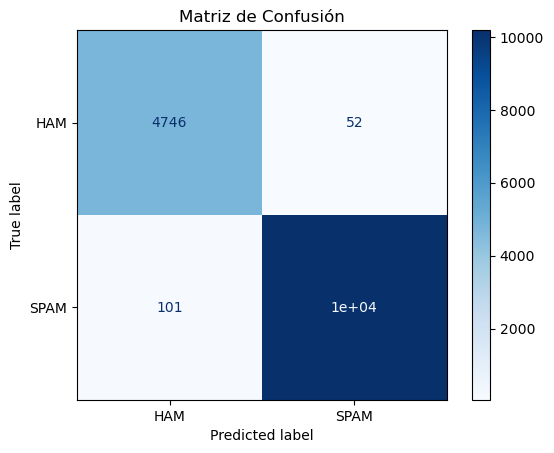

In [15]:
# La matriz de confusión muestra los 4 tipos de resultado posibles:
# Verdaderos Negativos (HAM bien clasificado)  | Falsos Positivos (HAM clasificado como SPAM)
# Falsos Negativos (SPAM no detectado)         | Verdaderos Positivos (SPAM bien detectado)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HAM', 'SPAM'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()


Es más probable que un correo SPAM se cuele en la bandeja a que un correo legítimo sea bloqueado, algo muy importante pues sería un problema grave para el usuario.

# 5. Impacto del tamaño del Dataset

Comprobar que el accuracy mejora a medida que aumentan los datos

In [16]:
sizes = [500, 1000, 5000, 10000, 30000, len(df)]
results = []

for n in sizes:
    split = int(n * 0.8)
    X_sub = df['text'][:n]
    y_sub = df['label'][:n]

    vec = CountVectorizer(max_features=10000)
    X_tr = vec.fit_transform(X_sub[:split])
    X_te = vec.transform(X_sub[split:])

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_sub[:split])
    acc = accuracy_score(y_sub[split:], model.predict(X_te))
    results.append(acc)
    print(f"n={n:<7} → Accuracy: {acc:.3f}")

n=500     → Accuracy: 0.990
n=1000    → Accuracy: 0.985
n=5000    → Accuracy: 0.986
n=10000   → Accuracy: 0.992
n=30000   → Accuracy: 0.993
n=75419   → Accuracy: 0.990


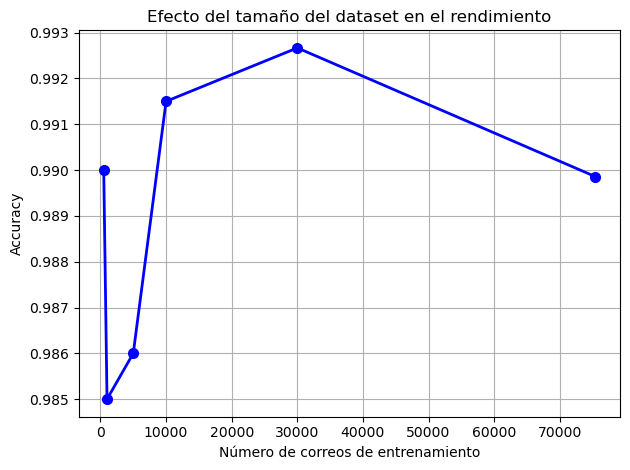

In [17]:
plt.plot(sizes, results, 'bo-', linewidth=2, markersize=7)
plt.xlabel("Número de correos de entrenamiento")
plt.ylabel("Accuracy")
plt.title("Efecto del tamaño del dataset en el rendimiento")
plt.grid(True)
plt.tight_layout()
plt.show()

El accuracy mejora conforme aumentan los datos de entrenamiento, pero suceden dos cosas: 
- Una caída inicial entre 500 y 1000 correos, que se debe a que con tan pocos datos el modelo es inestable
- Un descenso a partir de 30000 correos, probablemente porque el dataset completo introduce más variedad y casos difíciles de clasificar.